# Feature Selection

Uses XGBoost and AdaBoost feature importance to rank features.
Both are run inside PurgedKFold to avoid lookahead bias.

Features are ranked by mean importance across folds.
Agreement between the two methods signals robust features.

## Step 1 — Load & Prepare Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load feature matrix
df = pd.read_csv(r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\feature_matrix.csv",
                 index_col='date', parse_dates=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Label distribution:\n{df['bin'].value_counts().sort_index()}")

Shape: (5303, 169)
Date range: 2005-01-05 to 2026-02-02
Label distribution:
bin
-1.0    2771
 0.0      10
 1.0    2522
Name: count, dtype: int64


In [10]:
# Define feature columns
# drop volume and close as they are nonstationary(trend upward over time) and would leak future info. Also drop label and pivot artifact columns.
drop_cols = ['bin', 'ret',
             'corn_Close', 'soybean_Close',
             'corn_Volume', 'soybean_Volume']

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
    and 'locnan' not in c   # drop pivot artifact columns immediately
]

print(f"Number of features: {len(feature_cols)}")
print("Feature list:")
for f in feature_cols:
    print(f"  {f}")


Number of features: 124
Feature list:
  corn_log_return
  soybean_log_return
  temperature_2m_mean_loc1.0
  temperature_2m_mean_loc2.0
  temperature_2m_mean_loc3.0
  precipitation_sum_loc1.0
  precipitation_sum_loc2.0
  precipitation_sum_loc3.0
  dew_point_2m_mean_loc1.0
  dew_point_2m_mean_loc2.0
  dew_point_2m_mean_loc3.0
  cloud_cover_mean_loc1.0
  cloud_cover_mean_loc2.0
  cloud_cover_mean_loc3.0
  cloud_cover_max_loc1.0
  cloud_cover_max_loc2.0
  cloud_cover_max_loc3.0
  dew_point_2m_max_loc1.0
  dew_point_2m_max_loc2.0
  dew_point_2m_max_loc3.0
  dew_point_2m_min_loc1.0
  dew_point_2m_min_loc2.0
  dew_point_2m_min_loc3.0
  cloud_cover_min_loc1.0
  cloud_cover_min_loc2.0
  cloud_cover_min_loc3.0
  apparent_temperature_mean_loc1.0
  apparent_temperature_mean_loc2.0
  apparent_temperature_mean_loc3.0
  et0_fao_evapotranspiration_sum_loc1.0
  et0_fao_evapotranspiration_sum_loc2.0
  et0_fao_evapotranspiration_sum_loc3.0
  relative_humidity_2m_mean_loc1.0
  relative_humidity_2m_mean_lo

In [11]:
# Build X and y
X = df[feature_cols].copy()
y_raw = df['bin'].copy()

# Step 1: drop _locnan columns (entirely NaN — artifact of pivot)
locnan_cols = [c for c in X.columns if 'locnan' in c]
print(f"Dropping {len(locnan_cols)} _locnan columns (entirely NaN)")
X = X.drop(columns=locnan_cols)

# Step 2: drop columns that are >80% NaN (not worth imputing)
thresh = int(0.8 * len(X))
before = X.shape[1]
X = X.dropna(axis=1, thresh=thresh)
print(f"Dropped {before - X.shape[1]} columns with >80% NaN  ({X.shape[1]} remaining)")

# Step 3: impute remaining NaNs
# Rolling/lag features: forward-fill then backward-fill warm-up NaNs
roll_cols = [c for c in X.columns if any(k in c for k in ['z_score', 'lag', 'spread'])]
X[roll_cols] = X[roll_cols].ffill().bfill()

# Everything else: fill with column median (robust to outliers) (note: this can leak some info if NaNs are not random, but should be fine for a simple baseline)
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(X[col].median())

remaining_nan = X.isna().sum().sum()
print(f"NaNs remaining after imputation: {remaining_nan}")
assert remaining_nan == 0, "Still have NaNs — check imputation logic"

# Step 4: drop rows where label is NaN
valid = y_raw.notna()
X = X[valid]
y_raw = y_raw[valid]

# Step 5: remap labels to 0/1/2 for sklearn/XGBoost
# -1 -> 0 (SL hit), 0 -> 1 (time-out), 1 -> 2 (PT hit)
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
y = y_raw.map(label_map).astype(int)

print(f"Final X shape: {X.shape}")
print(f"y distribution:")
print(y.value_counts().sort_index())
print("  0 = Stop Loss  |  1 = Time-out  |  2 = Profit Take")
print(f"Feature list ({len(X.columns)} features):")
for c in X.columns:
    print(f"  {c}")


Dropping 0 _locnan columns (entirely NaN)
Dropped 0 columns with >80% NaN  (124 remaining)
NaNs remaining after imputation: 0
Final X shape: (5303, 124)
y distribution:
bin
0    2771
1      10
2    2522
Name: count, dtype: int64
  0 = Stop Loss  |  1 = Time-out  |  2 = Profit Take
Feature list (124 features):
  corn_log_return
  soybean_log_return
  temperature_2m_mean_loc1.0
  temperature_2m_mean_loc2.0
  temperature_2m_mean_loc3.0
  precipitation_sum_loc1.0
  precipitation_sum_loc2.0
  precipitation_sum_loc3.0
  dew_point_2m_mean_loc1.0
  dew_point_2m_mean_loc2.0
  dew_point_2m_mean_loc3.0
  cloud_cover_mean_loc1.0
  cloud_cover_mean_loc2.0
  cloud_cover_mean_loc3.0
  cloud_cover_max_loc1.0
  cloud_cover_max_loc2.0
  cloud_cover_max_loc3.0
  dew_point_2m_max_loc1.0
  dew_point_2m_max_loc2.0
  dew_point_2m_max_loc3.0
  dew_point_2m_min_loc1.0
  dew_point_2m_min_loc2.0
  dew_point_2m_min_loc3.0
  cloud_cover_min_loc1.0
  cloud_cover_min_loc2.0
  cloud_cover_min_loc3.0
  apparent_temper

## Step 2 — PurgedKFold Setup

Same cross-validation scheme as the validation notebook — prevents leakage.

In [12]:
class PurgedKFold(KFold):
    """
    K-Fold with purging and embargo for financial time series.
    """
    def __init__(self, n_splits=5, t1=None, pct_embargo=0.0):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.t1 = t1
        self.pct_embargo = pct_embargo

    def split(self, X, y=None, groups=None):
        if not isinstance(X.index, pd.DatetimeIndex):
            raise ValueError("X must have a DatetimeIndex.")

        mbrg = int(X.shape[0] * self.pct_embargo)

        for train_idx, test_idx in super().split(X, y, groups):
            test_start  = X.index[test_idx[0]]
            test_end    = X.index[test_idx[-1]]
            embargo_idx = min(test_idx[-1] + mbrg, X.shape[0] - 1)
            embargo_end = X.index[embargo_idx]

            t1_train = self.t1.iloc[train_idx]
            purged   = []

            for i, t1_val in zip(train_idx, t1_train.values):
                t0_val = X.index[i]
                if t1_val >= test_start and t0_val <= test_end:
                    continue
                if test_end <= t0_val < embargo_end:
                    continue
                purged.append(i)

            yield np.array(purged), test_idx


# t1 = event end times (needed for purging)
# We use the index shifted by 60 days as a proxy since we don't have the
# events DataFrame here — matches the 60-day vertical barrier from labelling
t1_proxy = pd.Series(
    X.index[np.clip(
        X.index.searchsorted(X.index + pd.Timedelta(days=60)),
        0, len(X.index) - 1
    )],
    index=X.index
)

cv = PurgedKFold(n_splits=5, t1=t1_proxy, pct_embargo=0.01)
print("PurgedKFold ready — 5 folds, 1% embargo")

PurgedKFold ready — 5 folds, 1% embargo


In [13]:
# ── DEBUG: check state before running models ──────────────────────────────────
print('=== X ===')
print(f'Shape: {X.shape}')
print(f'Type of index: {type(X.index)}')
print(f'NaNs remaining: {X.isna().sum().sum()}')
print()
print('=== y ===')
print(f'Shape: {y.shape}')
print(f'Values: {y.value_counts().sort_index().to_dict()}')
print()
print('=== t1_proxy ===')
print(f'Shape: {t1_proxy.shape}')
print(f'Index matches X: {t1_proxy.index.equals(X.index)}')
print()
print('=== feature_cols ===')
print(f'Count: {len(feature_cols)}')
print(f'First 5: {feature_cols[:5]}')


=== X ===
Shape: (5303, 124)
Type of index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
NaNs remaining: 0

=== y ===
Shape: (5303,)
Values: {0: 2771, 1: 10, 2: 2522}

=== t1_proxy ===
Shape: (5303,)
Index matches X: True

=== feature_cols ===
Count: 124
First 5: ['corn_log_return', 'soybean_log_return', 'temperature_2m_mean_loc1.0', 'temperature_2m_mean_loc2.0', 'temperature_2m_mean_loc3.0']


## Step 3 — XGBoost Feature Importance

In [14]:
xgb_importances = pd.DataFrame(index=feature_cols)

xgb_model = XGBClassifier(
    n_estimators=300, # 300 trees in ensemble
    max_depth=4, # each tree can have max depth of 4 (avoid overfitting)
    learning_rate=0.05, # each new tree contributes 5% to final prediction (slow down learning for better generalization)
    subsample=0.8, # each tree trained on 80% of data (randomly sampled, without replacement)
    colsample_bytree=0.8, # each tree considers 80% of features when looking for best split
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
)

xgb_accs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model.fit(X_train, y_train)

    acc = accuracy_score(y_test, xgb_model.predict(X_test))
    xgb_accs.append(acc)

    imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)
    xgb_importances[f'fold_{fold+1}'] = imp

    print(f"Fold {fold+1}: accuracy = {acc:.3f}")

xgb_importances['mean'] = xgb_importances.mean(axis=1)
xgb_importances['std']  = xgb_importances.drop(columns='mean').std(axis=1)
xgb_importances = xgb_importances.sort_values('mean', ascending=False)

print(f"\nMean CV accuracy (XGBoost): {np.mean(xgb_accs):.3f} ± {np.std(xgb_accs):.3f}")

Fold 1: accuracy = 0.538
Fold 2: accuracy = 0.514
Fold 3: accuracy = 0.534
Fold 4: accuracy = 0.513
Fold 5: accuracy = 0.525

Mean CV accuracy (XGBoost): 0.525 ± 0.010


## Step 4 — AdaBoost Feature Importance

In [15]:
ada_importances = pd.DataFrame(index=feature_cols)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
)

ada_accs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ada_model.fit(X_train, y_train)

    acc = accuracy_score(y_test, ada_model.predict(X_test))
    ada_accs.append(acc)

    imp = pd.Series(ada_model.feature_importances_, index=feature_cols)
    ada_importances[f'fold_{fold+1}'] = imp

    print(f"Fold {fold+1}: accuracy = {acc:.3f}")

ada_importances['mean'] = ada_importances.mean(axis=1)
ada_importances['std']  = ada_importances.drop(columns='mean').std(axis=1)
ada_importances = ada_importances.sort_values('mean', ascending=False)

print(f"\nMean CV accuracy (AdaBoost): {np.mean(ada_accs):.3f} ± {np.std(ada_accs):.3f}")

Fold 1: accuracy = 0.550
Fold 2: accuracy = 0.519
Fold 3: accuracy = 0.498
Fold 4: accuracy = 0.513
Fold 5: accuracy = 0.524

Mean CV accuracy (AdaBoost): 0.521 ± 0.017


## Step 5 — Results: Top 20 Features per Method

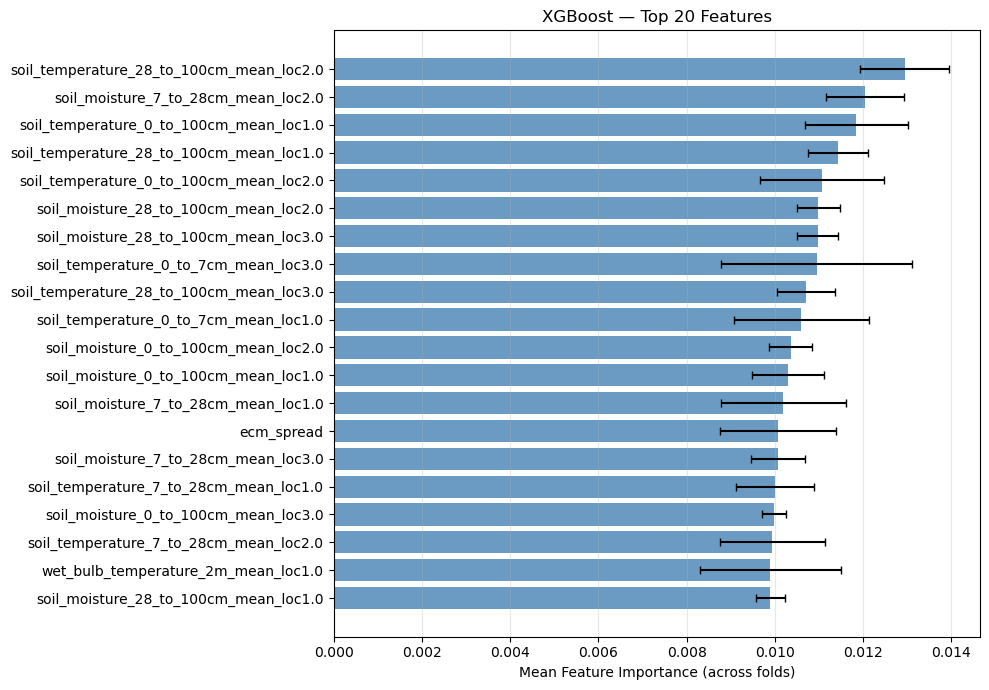

In [16]:
top_n = 20

# XGBoost plot
fig, ax = plt.subplots(figsize=(10, 7))

top_xgb = xgb_importances['mean'].head(top_n)
top_xgb_std = xgb_importances['std'].head(top_n)

bars = ax.barh(top_xgb.index[::-1], top_xgb.values[::-1],
               xerr=top_xgb_std.values[::-1],
               color='steelblue', alpha=0.8, capsize=3)

ax.set_xlabel('Mean Feature Importance (across folds)')
ax.set_title(f'XGBoost — Top {top_n} Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

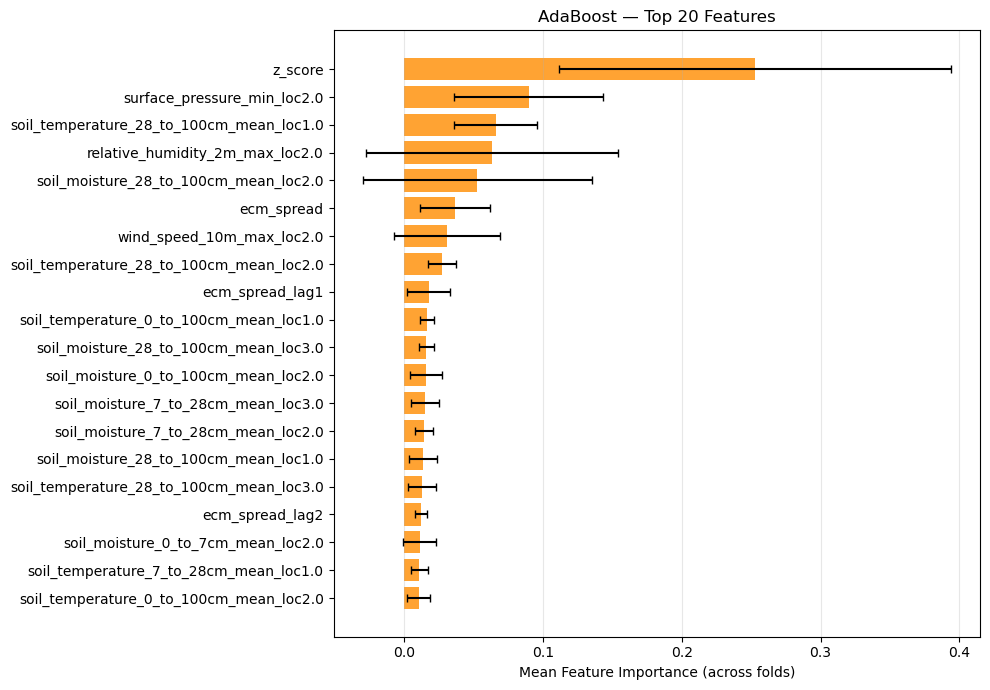

In [17]:
# AdaBoost plot 
fig, ax = plt.subplots(figsize=(10, 7))

top_ada = ada_importances['mean'].head(top_n)
top_ada_std = ada_importances['std'].head(top_n)

bars = ax.barh(top_ada.index[::-1], top_ada.values[::-1],
               xerr=top_ada_std.values[::-1],
               color='darkorange', alpha=0.8, capsize=3)

ax.set_xlabel('Mean Feature Importance (across folds)')
ax.set_title(f'AdaBoost — Top {top_n} Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Agreement Table

Features that rank highly in **both** methods are the most trustworthy candidates.

In [18]:
# Rank each feature (1 = most important)
xgb_rank = xgb_importances['mean'].rank(ascending=False).rename('xgb_rank')
ada_rank = ada_importances['mean'].rank(ascending=False).rename('ada_rank')

comparison = pd.concat([
    xgb_importances['mean'].rename('xgb_importance'),
    ada_importances['mean'].rename('ada_importance'),
    xgb_rank,
    ada_rank,
], axis=1)

# Mean rank across both methods — lower is better
comparison['mean_rank'] = (comparison['xgb_rank'] + comparison['ada_rank']) / 2
comparison = comparison.sort_values('mean_rank')

print("Top 20 features by combined rank:")
print(comparison.head(20).to_string(float_format=lambda x: f"{x:.4f}"))

Top 20 features by combined rank:
                                          xgb_importance  ada_importance  xgb_rank  ada_rank  mean_rank
soil_temperature_28_to_100cm_mean_loc1.0          0.0114          0.0658    4.0000    3.0000     3.5000
soil_temperature_28_to_100cm_mean_loc2.0          0.0129          0.0271    1.0000    8.0000     4.5000
soil_moisture_28_to_100cm_mean_loc2.0             0.0110          0.0526    6.0000    5.0000     5.5000
soil_temperature_0_to_100cm_mean_loc1.0           0.0118          0.0163    3.0000   10.0000     6.5000
soil_moisture_7_to_28cm_mean_loc2.0               0.0120          0.0145    2.0000   14.0000     8.0000
soil_moisture_28_to_100cm_mean_loc3.0             0.0110          0.0159    7.0000   11.0000     9.0000
ecm_spread                                        0.0101          0.0365   14.0000    6.0000    10.0000
soil_moisture_0_to_100cm_mean_loc2.0              0.0104          0.0154   11.0000   12.0000    11.5000
soil_temperature_28_to_100cm_m

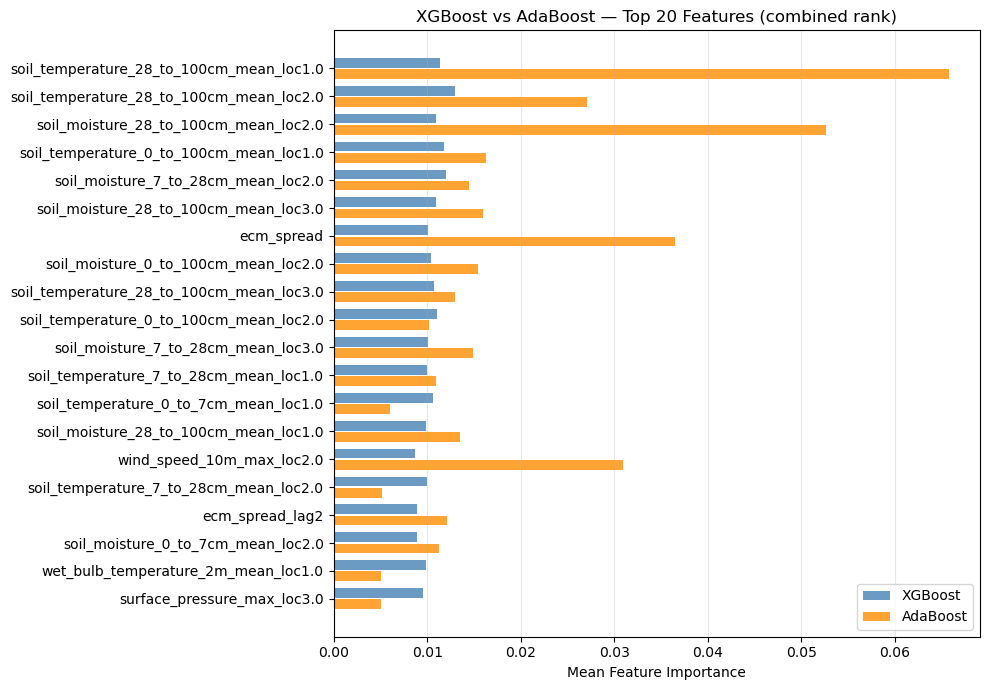

In [19]:
# Side-by-side rank comparison for top 20
top20 = comparison.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(top20))
ax.barh(y_pos - 0.2, top20['xgb_importance'], height=0.35,
        label='XGBoost', color='steelblue', alpha=0.8)
ax.barh(y_pos + 0.2, top20['ada_importance'], height=0.35,
        label='AdaBoost', color='darkorange', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel('Mean Feature Importance')
ax.set_title('XGBoost vs AdaBoost — Top 20 Features (combined rank)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Selected Feature Set

Keep features that rank in the **top 20 in at least one method** AND have **mean rank ≤ 15**.
Adjust thresholds based on what the plots show.

In [20]:
# Threshold: keep features with mean_rank <= 15
RANK_THRESHOLD = 15

selected = comparison[comparison['mean_rank'] <= RANK_THRESHOLD].index.tolist()

print(f"Selected {len(selected)} features (mean_rank <= {RANK_THRESHOLD}):")
for f in selected:
    row = comparison.loc[f]
    print(f"  {f:<45s}  xgb_rank={row['xgb_rank']:5.1f}  ada_rank={row['ada_rank']:5.1f}")

# Save selected feature list
pd.Series(selected, name='selected_features').to_csv(
    r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\selected_features.csv", index=False
)
print("\nSaved to selected_features.csv")

Selected 11 features (mean_rank <= 15):
  soil_temperature_28_to_100cm_mean_loc1.0       xgb_rank=  4.0  ada_rank=  3.0
  soil_temperature_28_to_100cm_mean_loc2.0       xgb_rank=  1.0  ada_rank=  8.0
  soil_moisture_28_to_100cm_mean_loc2.0          xgb_rank=  6.0  ada_rank=  5.0
  soil_temperature_0_to_100cm_mean_loc1.0        xgb_rank=  3.0  ada_rank= 10.0
  soil_moisture_7_to_28cm_mean_loc2.0            xgb_rank=  2.0  ada_rank= 14.0
  soil_moisture_28_to_100cm_mean_loc3.0          xgb_rank=  7.0  ada_rank= 11.0
  ecm_spread                                     xgb_rank= 14.0  ada_rank=  6.0
  soil_moisture_0_to_100cm_mean_loc2.0           xgb_rank= 11.0  ada_rank= 12.0
  soil_temperature_28_to_100cm_mean_loc3.0       xgb_rank=  9.0  ada_rank= 16.0
  soil_temperature_0_to_100cm_mean_loc2.0        xgb_rank=  5.0  ada_rank= 20.0
  soil_moisture_7_to_28cm_mean_loc3.0            xgb_rank= 15.0  ada_rank= 13.0

Saved to selected_features.csv
